1. задание
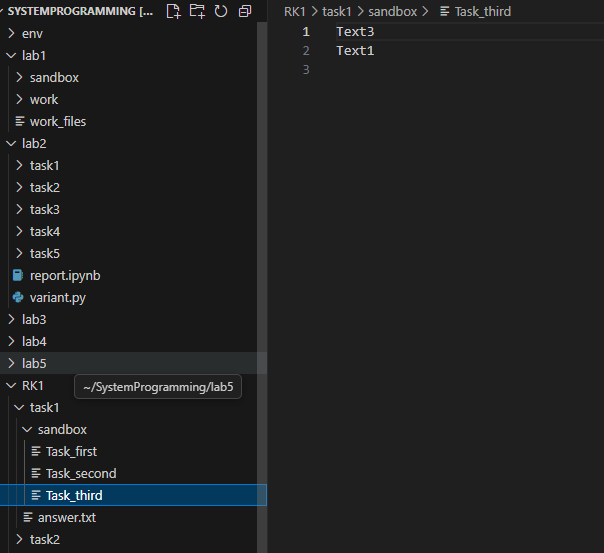

In [ ]:
mkdir sandbox
cd sandbox

touch Task_1
touch Task_2
touch Task_3

ls -l --block-size=K Task_1 Task_2 Task_3

mv Task_1 Task_first
mv Task_2 Task_second
mv Task_3 Task_third

cat Task_first >> Task_third


In [ ]:
format ELF64
public _start

include '../../help.asm'
include '../../func.asm'

section '.data' writable
    msg_n db 'Введите n: ', 0
    msg_k db 'Введите k: ', 0
    msg_result db 'Сумма чисел с суммой цифр k: ', 0

section '.bss' writable
    buffer rb 256
    n dq 0
    k dq 0
    sum dq 0

section '.text' executable
sum_of_digits:
    push rbx
    push rcx
    push rdx

    mov rbx, 10
    xor rcx, rcx    ; сумма цифр

.calculate:
    xor rdx, rdx
    div rbx         ; rdx = последняя цифра
    add rcx, rdx    ; к сумме добавляется цифра
    test rax, rax
    jnz .calculate

    mov rax, rcx

    pop rdx
    pop rcx
    pop rbx
    ret

_start:
    mov rsi, msg_n
    call print_str

    mov rsi, buffer
    call input_keyboard
    call atoi
    mov [n], rax

    mov rsi, msg_k
    call print_str

    mov rsi, buffer
    call input_keyboard
    call atoi
    mov [k], rax

    mov rcx, 1      ;суммирование чисел от 1 до n с суммой k, начинаем с 1

.loop:
    cmp rcx, [n]
    jg .end_loop    ; если прошли все числа до n

    mov rax, rcx
    call sum_of_digits  ; сумма цифр текущего числа

    cmp rax, [k]
    jne .next_number    ; если сумма цифр не равна k, то скип

    add [sum], rcx

.next_number:
    inc rcx
    jmp .loop

.end_loop:
    mov rsi, msg_result
    call print_str

    mov rax, [sum]
    call print_int
    call new_line

    call exit


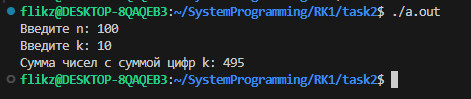

In [ ]:
format ELF64

public _start

section '.data' writeable
    msg_usage db "Usage: ./program <directory>", 10, 0
    msg_error_dir db "Ошибка открытия директории", 10, 0
    msg_error_files db "Ошибка: в каталоге меньше 2 файлов", 10, 0
    msg_success db "Отлично, содержимое поменяно местами", 10, 0
    newline db 10, 0

section '.bss' writeable
    dir_fd dq 0
    file_count dq 0
    dir_path dq 0

    buffer rb 8192
    dirent_buffer rb 1024
    file_names rb 256 * 256
    path_buffer rb 1024

section '.text' executable

_start:
    mov rax, [rsp]
    cmp rax, 2
    jne usage

    mov rax, [rsp + 16]
    mov [dir_path], rax

    mov rax, 2
    mov rdi, [dir_path]
    mov rsi, 0
    mov rdx, 0
    syscall
    cmp rax, 0
    jl error_dir
    mov [dir_fd], rax

    xor r15, r15
    lea r14, [file_names]

.read_dir_loop:
    mov rax, 217
    mov rdi, [dir_fd]
    mov rsi, dirent_buffer
    mov rdx, 1024
    syscall
    test rax, rax
    jle dir_read_done

    mov r13, rax
    xor r12, r12

.process_dirent:
    lea rbx, [dirent_buffer + r12]

    movzx ecx, word [rbx + 16]
    test cx, cx
    jz dir_read_done

    mov al, byte [rbx + 19]
    cmp al, '.'
    je .next_dirent

    mov al, byte [rbx + 18]
    cmp al, 8
    jne .next_dirent

    lea rsi, [rbx + 19]
    mov rdi, r14
    call strcpy

    add r14, 256
    inc r15

    cmp r15, 256
    jge dir_read_done

.next_dirent:
    add r12, rcx
    cmp r12, r13
    jl .process_dirent
    jmp .read_dir_loop

dir_read_done:
    mov rax, 3
    mov rdi, [dir_fd]
    syscall

    mov [file_count], r15

    cmp r15, 2
    jl error_files

    call get_random_index
    mov r12, rax

.get_second_index:
    call get_random_index
    cmp rax, r12
    je .get_second_index
    mov r13, rax

    lea rbx, [file_names]

    mov rax, 256
    mul r12
    lea rsi, [rbx + rax]
    lea rdi, [path_buffer]
    call make_full_path
    lea r14, [path_buffer]

    mov rax, 256
    mul r13
    lea rsi, [rbx + rax]
    lea rdi, [path_buffer + 512]
    call make_full_path
    lea r15, [path_buffer + 512]

    mov rdi, r14
    mov rsi, r15
    call swap_files

    mov rsi, msg_success
    call print_str
    jmp exit

usage:
    mov rsi, msg_usage
    call print_str
    jmp exit

error_dir:
    mov rsi, msg_error_dir
    call print_str
    jmp exit

error_files:
    mov rsi, msg_error_files
    call print_str
    jmp exit

exit:
    mov rax, 60
    mov rdi, 0
    syscall

make_full_path:
    push rax
    push rsi
    push rdi

    mov rsi, [dir_path]
.copy_dir:
    mov al, [rsi]
    mov [rdi], al
    test al, al
    jz .add_slash
    inc rsi
    inc rdi
    jmp .copy_dir

.add_slash:
    dec rdi
    mov al, [rdi]
    cmp al, '/'
    je .copy_filename
    inc rdi
    mov byte [rdi], '/'
    inc rdi

.copy_filename:
    pop rsi
    push rsi
    mov rsi, [rsp + 8]
.copy_name:
    mov al, [rsi]
    mov [rdi], al
    test al, al
    jz .done
    inc rsi
    inc rdi
    jmp .copy_name

.done:
    pop rdi
    pop rsi
    pop rax
    ret

swap_files:
    push r12
    push r13
    push r14
    push r15

    mov r14, rdi
    mov r15, rsi

    mov rax, 2
    mov rdi, r14
    xor rsi, rsi
    xor rdx, rdx
    syscall
    cmp rax, 0
    jl .swap_error
    mov r12, rax

    mov rax, 2
    mov rdi, r15
    xor rsi, rsi
    xor rdx, rdx
    syscall
    cmp rax, 0
    jl .swap_error
    mov r13, rax

    mov rax, 0
    mov rdi, r12
    mov rsi, buffer
    mov rdx, 4096
    syscall
    cmp rax, 0
    jl .swap_error
    push rax

    mov rax, 0
    mov rdi, r13
    mov rsi, buffer + 4096
    mov rdx, 4096
    syscall
    cmp rax, 0
    jl .swap_error
    push rax

    mov rax, 3
    mov rdi, r12
    syscall

    mov rax, 3
    mov rdi, r13
    syscall

    mov rax, 2
    mov rdi, r14
    mov rsi, 0x241
    mov rdx, 0644o
    syscall
    cmp rax, 0
    jl .swap_error
    mov r12, rax

    mov rax, 1
    mov rdi, r12
    mov rsi, buffer + 4096
    pop rdx
    syscall

    mov rax, 3
    mov rdi, r12
    syscall

    mov rax, 2
    mov rdi, r15
    mov rsi, 0x241
    mov rdx, 0644o
    syscall
    cmp rax, 0
    jl .swap_error
    mov r13, rax

    mov rax, 1
    mov rdi, r13
    mov rsi, buffer
    pop rdx
    syscall

    mov rax, 3
    mov rdi, r13
    syscall

    pop r15
    pop r14
    pop r13
    pop r12
    ret

.swap_error:
    cmp r12, 0
    jle .close_file2
    mov rax, 3
    mov rdi, r12
    syscall
.close_file2:
    cmp r13, 0
    jle .swap_done
    mov rax, 3
    mov rdi, r13
    syscall
.swap_done:
    pop r15
    pop r14
    pop r13
    pop r12
    ret

get_random_index:
    push rbx
    push rdx

    mov rax, 201
    xor rdi, rdi
    syscall

    xor rdx, rdx
    mov rbx, [file_count]
    test rbx, rbx
    jz .zero
    div rbx
    mov rax, rdx
    jmp .done
.zero:
    xor rax, rax
.done:
    pop rdx
    pop rbx
    ret

strcpy:
    push rax
.loop:
    mov al, [rsi]
    mov [rdi], al
    test al, al
    jz .done
    inc rsi
    inc rdi
    jmp .loop
.done:
    pop rax
    ret

print_str:
    push rax
    push rdi
    push rsi
    push rdx
    push rcx
    push r11

    mov rdi, rsi
    call strlen
    mov rdx, rax

    mov rax, 1
    mov rdi, 1
    syscall

    pop r11
    pop rcx
    pop rdx
    pop rsi
    pop rdi
    pop rax
    ret

strlen:
    push rcx
    mov rcx, rsi
    xor rax, rax
.loop:
    cmp byte [rcx + rax], 0
    je .done
    inc rax
    jmp .loop
.done:
    pop rcx
    ret


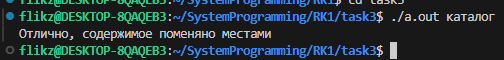